# Inspect LeRobot datasets (v2 + v3)

Look at whatever is sitting under `~/.cache/huggingface/lerobot/`: list available
datasets, read the metadata, open one episode, plot the trajectories, and pull a few
frames out of the matching mp4.

Handles **both** layouts:
- **v2** — one parquet + mp4 per episode, `meta/episodes.jsonl`
- **v3** — bundled parquet + mp4 per chunk, `meta/episodes/.../file-NNN.parquet` for routing

Run inside the `jazzy-lerobot` pixi env:

```bash
cd ~/Coding/Robot_Control/Yunfei/crisp_gym
pixi run -e jazzy-lerobot jupyter lab notebooks/inspect_dataset.ipynb
```

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LEROBOT_CACHE = Path(os.environ.get("HF_LEROBOT_HOME", Path.home() / ".cache/huggingface/lerobot"))
print(f"LeRobot cache: {LEROBOT_CACHE}")
print(f"Exists: {LEROBOT_CACHE.exists()}")

LeRobot cache: /home/ali/.cache/huggingface/lerobot
Exists: True


## 1. Discover datasets

Any directory with `meta/info.json` is a dataset. Both v2 and v3 are detected.


In [2]:
def _v3_episode_count(dataset_dir: Path, info: dict) -> tuple[int, int]:
    """Return (episode_count, total_frames) for a v3 dataset by reading meta/episodes/*."""
    ep_dir = dataset_dir / "meta" / "episodes"
    if not ep_dir.exists():
        return int(info.get("total_episodes", 0)), int(info.get("total_frames", 0))
    parts = sorted(ep_dir.rglob("file-*.parquet"))
    if not parts:
        return int(info.get("total_episodes", 0)), int(info.get("total_frames", 0))
    n_eps = 0
    n_frames = 0
    for p in parts:
        d = pd.read_parquet(p, columns=["episode_index", "length"])
        n_eps += len(d)
        n_frames += int(d["length"].sum())
    return n_eps, n_frames


def _v2_episode_count(dataset_dir: Path) -> tuple[int, int]:
    ep_path = dataset_dir / "meta" / "episodes.jsonl"
    if not ep_path.exists():
        return 0, 0
    n_eps = 0
    n_frames = 0
    with open(ep_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                ep = json.loads(line)
            except json.JSONDecodeError:
                continue
            n_eps += 1
            n_frames += int(ep.get("length", 0))
    return n_eps, n_frames


def discover_datasets(root: Path) -> list[dict]:
    """Walk the LeRobot cache and return one row per dataset (v2 or v3)."""
    rows: list[dict] = []
    if not root.exists():
        return rows
    for info_path in sorted(root.rglob("meta/info.json")):
        dataset_dir = info_path.parent.parent
        repo_id = str(dataset_dir.relative_to(root))
        try:
            with open(info_path) as f:
                info = json.load(f)
        except Exception as exc:
            rows.append({"repo_id": repo_id, "error": str(exc)})
            continue
        version = str(info.get("codebase_version", "v?"))
        if version.startswith("v3"):
            n_eps, n_frames = _v3_episode_count(dataset_dir, info)
        else:
            n_eps, n_frames = _v2_episode_count(dataset_dir)
        rows.append({
            "repo_id": repo_id,
            "version": version,
            "fps": info.get("fps"),
            "robot_type": info.get("robot_type"),
            "total_episodes": n_eps,
            "total_frames": n_frames,
            "mtime": dataset_dir.stat().st_mtime,
            "path": dataset_dir,
        })
    return rows


datasets = discover_datasets(LEROBOT_CACHE)
if not datasets:
    print("No LeRobot datasets found.")
else:
    df_disc = pd.DataFrame(datasets).sort_values("mtime", ascending=False)
    cols = ["repo_id", "version", "fps", "robot_type", "total_episodes", "total_frames"]
    display(df_disc[cols])

,repo_id,version,fps,robot_type,total_episodes,total_frames
9,ridgeback_223335,v3.0,20,ur10e,2,1987
8,ridgeback_222129,v3.0,20,ur10e,0,0
7,ridgeback_221852,v3.0,20,ur10e,0,0
4,ridgeback,v3.0,20,ur10e,1,188
6,ridgeback_210719,v3.0,20,ur10e,0,0
5,ridgeback_210503,v3.0,20,ur10e,0,0
3,pick_red_cube_003,v3.0,20,ur10e,2,119
2,pick_red_cube_002,v3.0,20,ur10e,2,71
1,pick_red_cube_001,v3.0,20,ur10e,2,844
0,mishmish66/mimicgen_coffee_d0,v2.1,20,panda,1000,223130


## 2. Pick a dataset

Default: most recently modified `ridgeback*` dataset. Override `REPO_ID` to pick another.


In [3]:
def _pick_default(rows: list[dict]) -> str:
    if not rows:
        raise FileNotFoundError("No datasets in the LeRobot cache.")
    ridgebacks = [r for r in rows if r["repo_id"].startswith("ridgeback")]
    pool = ridgebacks if ridgebacks else rows
    return max(pool, key=lambda r: r["mtime"])["repo_id"]


REPO_ID = _pick_default(datasets)  # or set manually, e.g. REPO_ID = "ridgeback_223335"
DATASET_DIR = LEROBOT_CACHE / REPO_ID
print(f"Selected: {REPO_ID}")
print(f"Path:     {DATASET_DIR}")

Selected: ridgeback_223335
Path:     /home/ali/.cache/huggingface/lerobot/ridgeback_223335


## 3. DatasetReader (v2 + v3 abstraction)

A small reader that hides the layout difference. Exposes:

- `reader.info` — raw `info.json` dict
- `reader.version` — e.g. `"v3.0"`
- `reader.fps`
- `reader.episodes_df` — one row per episode (`episode_index`, `length`, `tasks`)
- `reader.load_episode(idx)` — frames for one episode as a DataFrame
- `reader.episode_video_specs(idx)` — `{video_key: (mp4_path, from_ts, to_ts)}`


In [4]:
class DatasetReader:
    """Uniform reader for LeRobot v2 and v3 datasets on disk."""

    def __init__(self, dataset_dir: Path):
        self.dataset_dir = Path(dataset_dir)
        with open(self.dataset_dir / "meta" / "info.json") as f:
            self.info: dict[str, Any] = json.load(f)
        self.version: str = str(self.info.get("codebase_version", "v?"))
        self.fps: float = float(self.info.get("fps", 20))
        self._is_v3 = self.version.startswith("v3")
        self._episodes_df: pd.DataFrame | None = None
        self._v3_data_cache: dict[Path, pd.DataFrame] = {}

    @property
    def episodes_df(self) -> pd.DataFrame:
        if self._episodes_df is not None:
            return self._episodes_df
        if self._is_v3:
            parts = sorted((self.dataset_dir / "meta" / "episodes").rglob("file-*.parquet"))
            self._episodes_df = (
                pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
                if parts else pd.DataFrame()
            )
        else:
            rows: list[dict] = []
            ep_path = self.dataset_dir / "meta" / "episodes.jsonl"
            if ep_path.exists():
                with open(ep_path) as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            try:
                                rows.append(json.loads(line))
                            except json.JSONDecodeError:
                                pass
            self._episodes_df = pd.DataFrame(rows)
        return self._episodes_df

    def load_episode(self, episode_index: int) -> pd.DataFrame:
        if self._is_v3:
            ep_row = self.episodes_df.loc[
                self.episodes_df["episode_index"] == episode_index
            ]
            if ep_row.empty:
                raise KeyError(f"episode_index {episode_index} not found")
            chunk = int(ep_row.iloc[0]["data/chunk_index"])
            file_idx = int(ep_row.iloc[0]["data/file_index"])
            tmpl = self.info.get(
                "data_path",
                "data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet",
            )
            rel = tmpl.format(chunk_index=chunk, file_index=file_idx)
            path = self.dataset_dir / rel
            if path not in self._v3_data_cache:
                self._v3_data_cache[path] = pd.read_parquet(path)
            d = self._v3_data_cache[path]
            return d[d["episode_index"] == episode_index].reset_index(drop=True)
        else:
            path = self.dataset_dir / "data" / "chunk-000" / f"episode_{episode_index:06d}.parquet"
            return pd.read_parquet(path)

    def episode_video_specs(self, episode_index: int) -> dict[str, tuple[Path, float, float]]:
        """Return {video_key: (mp4_path, from_ts, to_ts)} for an episode."""
        out: dict[str, tuple[Path, float, float]] = {}
        if self._is_v3:
            ep_row = self.episodes_df.loc[
                self.episodes_df["episode_index"] == episode_index
            ]
            if ep_row.empty:
                return out
            row = ep_row.iloc[0]
            tmpl = self.info.get(
                "video_path",
                "videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4",
            )
            video_keys = [
                k for k, v in (self.info.get("features") or {}).items()
                if isinstance(v, dict) and v.get("dtype") == "video"
            ]
            for key in video_keys:
                chunk_col = f"videos/{key}/chunk_index"
                file_col = f"videos/{key}/file_index"
                from_col = f"videos/{key}/from_timestamp"
                to_col = f"videos/{key}/to_timestamp"
                if chunk_col not in self.episodes_df.columns:
                    continue
                rel = tmpl.format(
                    video_key=key,
                    chunk_index=int(row[chunk_col]),
                    file_index=int(row[file_col]),
                )
                mp4 = self.dataset_dir / rel
                if mp4.exists():
                    out[key] = (mp4, float(row[from_col]), float(row[to_col]))
            return out
        else:
            video_root = self.dataset_dir / "videos" / "chunk-000"
            if not video_root.exists():
                return out
            d = self.load_episode(episode_index)
            duration = len(d) / self.fps
            for cam_dir in sorted(video_root.iterdir()):
                ep_mp4 = cam_dir / f"episode_{episode_index:06d}.mp4"
                if ep_mp4.exists():
                    out[cam_dir.name] = (ep_mp4, 0.0, duration)
            return out


reader = DatasetReader(DATASET_DIR)
print(f"Version: {reader.version}    fps: {reader.fps}")
print(f"Episodes: {len(reader.episodes_df)}")

Version: v3.0    fps: 20.0
Episodes: 2


## 4. Metadata dump


In [5]:
info = reader.info
print("=== info.json top-level keys ===")
print(list(info.keys()))
print()
print(f"codebase_version: {reader.version}")
print(f"fps             : {info.get('fps')}")
print(f"robot_type      : {info.get('robot_type')}")
print(f"total_episodes  : {info.get('total_episodes')}")
print(f"total_frames    : {info.get('total_frames')}")
print()
print("=== features ===")
for k, v in (info.get("features") or {}).items():
    dtype = v.get("dtype", "?")
    shape = v.get("shape", "?")
    names = v.get("names")
    if isinstance(names, list) and len(names) > 6:
        names_str = f"{names[:3]} \u2026 ({len(names)} total)"
    else:
        names_str = str(names)
    print(f"  {k:40s}  dtype={dtype:8s}  shape={shape}  names={names_str}")

=== info.json top-level keys ===
['codebase_version', 'robot_type', 'total_episodes', 'total_frames', 'total_tasks', 'chunks_size', 'data_files_size_in_mb', 'video_files_size_in_mb', 'fps', 'splits', 'data_path', 'video_path', 'features']

codebase_version: v3.0
fps             : 20
robot_type      : ur10e
total_episodes  : 2
total_frames    : 1987

=== features ===
  observation.images.camera                 dtype=video     shape=[640, 480, 3]  names=['height', 'width', 'channels']
  observation.state.cartesian               dtype=float32   shape=[6]  names=['x', 'y', 'z', 'roll', 'pitch', 'yaw']
  observation.state.gripper                 dtype=float32   shape=[1]  names=['gripper']
  observation.state.gripper_target          dtype=float32   shape=[1]  names=['gripper_target']
  observation.state.joints                  dtype=float32   shape=[6]  names=['joint_0', 'joint_1', 'joint_2', 'joint_3', 'joint_4', 'joint_5']
  observation.state.target                  dtype=float32   shape=

In [6]:
tasks_v3 = DATASET_DIR / "meta" / "tasks.parquet"
tasks_v2 = DATASET_DIR / "meta" / "tasks.jsonl"
if tasks_v3.exists():
    print("=== tasks.parquet ===")
    display(pd.read_parquet(tasks_v3))
elif tasks_v2.exists():
    print("=== tasks.jsonl ===")
    with open(tasks_v2) as f:
        for line in f:
            line = line.strip()
            if line:
                print("  ", line)
else:
    print("(no tasks file)")

=== tasks.parquet ===


,task_index
mocap teleop demo,0


In [7]:
ep_df = reader.episodes_df
if ep_df.empty:
    print("(no episodes)")
else:
    cols = [c for c in ["episode_index", "tasks", "length"] if c in ep_df.columns]
    display(ep_df[cols])

,episode_index,tasks,length
0,0,[mocap teleop demo],287
1,1,[mocap teleop demo],1700


## 5. Load one episode


In [8]:
EPISODE_INDEX = 0  # change to inspect a different episode

df = reader.load_episode(EPISODE_INDEX)
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

Shape: (287, 12)
Columns (12): ['observation.state.cartesian', 'observation.state.gripper', 'observation.state.gripper_target', 'observation.state.joints', 'observation.state.target', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [9]:
df.head(3)

,observation.state.cartesian,observation.state.gripper,observation.state.gripper_target,observation.state.joints,observation.state.target,observation.state,action,timestamp,frame_index,episode_index,index,task_index
0,"[0.8968223, 0.15437227, 0.86205584, 3.1007042,...",0.986759,1.0,"[1.6256055, -1.6268793, 1.5203061, -1.539637, ...","[0.8964433, 0.14388372, 0.85762566, 3.0470076,...","[0.8968223, 0.15437227, 0.86205584, 3.1007042,...","[0.8964433, 0.14388372, 0.85762566, 3.0470076,...",0.00,0,0,0,0
1,"[0.8968966, 0.15519695, 0.86208385, 3.0999053,...",0.986759,1.0,"[1.625584, -1.6268665, 1.5203179, -1.5396334, ...","[0.8973631, 0.14465316, 0.8555134, 3.051635, 0...","[0.8968966, 0.15519695, 0.86208385, 3.0999053,...","[0.8973631, 0.14465316, 0.8555134, 3.051635, 0...",0.05,1,0,1,0
2,"[0.8969997, 0.1569257, 0.861933, 3.0983098, 0....",0.986759,1.0,"[1.6258377, -1.6265365, 1.5203614, -1.5396215,...","[0.8989314, 0.1452224, 0.8515637, 3.0548155, 0...","[0.8969997, 0.1569257, 0.861933, 3.0983098, 0....","[0.8989314, 0.1452224, 0.8515637, 3.0548155, 0...",0.10,2,0,2,0


In [10]:
def _is_vector_col(series: pd.Series) -> bool:
    sample = next((v for v in series if v is not None), None)
    return isinstance(sample, (list, np.ndarray))

vector_cols = [c for c in df.columns if _is_vector_col(df[c])]
scalar_cols = [c for c in df.columns if c not in vector_cols]
print(f"Scalar columns ({len(scalar_cols)}): {scalar_cols}")
print(f"Vector columns ({len(vector_cols)}): {vector_cols}")

Scalar columns (7): ['observation.state.gripper', 'observation.state.gripper_target', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
Vector columns (5): ['observation.state.cartesian', 'observation.state.joints', 'observation.state.target', 'observation.state', 'action']


## 6. Trajectories


In [11]:
def stack(colname: str) -> np.ndarray | None:
    if colname not in df.columns:
        return None
    arr = np.stack([np.asarray(v, dtype=np.float32) for v in df[colname].values])
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr

if "timestamp" in df.columns:
    t = np.asarray(df["timestamp"].values, dtype=np.float32)
else:
    t = np.arange(len(df)) / float(reader.fps)

print(f"t shape: {t.shape}   t[0..2]={t[:3]}   t[-1]={t[-1]:.3f}")

t shape: (287,)   t[0..2]=[0.   0.05 0.1 ]   t[-1]=14.300


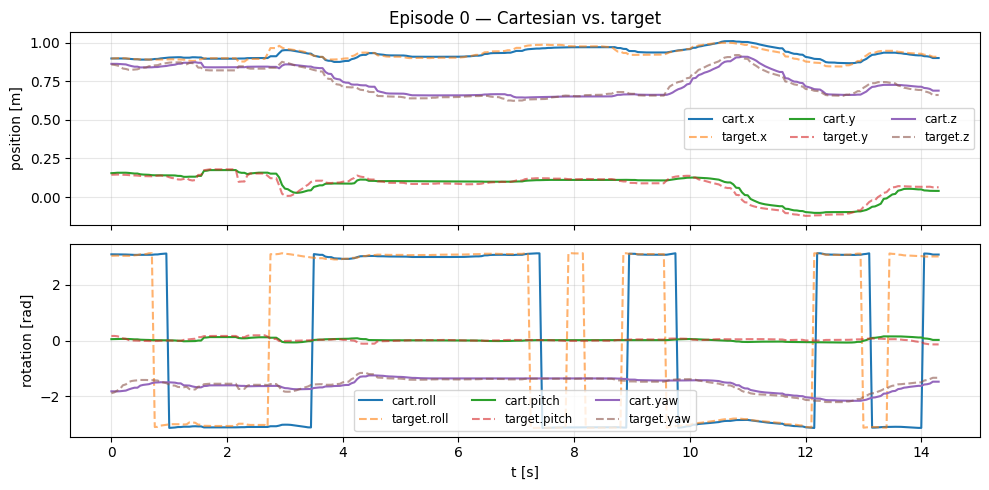

In [12]:
cart = stack("observation.state.cartesian")
tgt = stack("observation.state.target")

if cart is not None:
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    for i, label in enumerate(["x", "y", "z"]):
        axes[0].plot(t, cart[:, i], label=f"cart.{label}")
        if tgt is not None:
            axes[0].plot(t, tgt[:, i], linestyle="--", alpha=0.6, label=f"target.{label}")
    axes[0].set_ylabel("position [m]")
    axes[0].legend(ncol=3, fontsize="small")
    axes[0].grid(alpha=0.3)
    axes[0].set_title(f"Episode {EPISODE_INDEX} \u2014 Cartesian vs. target")
    for i, label in enumerate(["roll", "pitch", "yaw"]):
        axes[1].plot(t, cart[:, 3 + i], label=f"cart.{label}")
        if tgt is not None:
            axes[1].plot(t, tgt[:, 3 + i], linestyle="--", alpha=0.6, label=f"target.{label}")
    axes[1].set_ylabel("rotation [rad]")
    axes[1].set_xlabel("t [s]")
    axes[1].legend(ncol=3, fontsize="small")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
else:
    print("No observation.state.cartesian column in this dataset.")

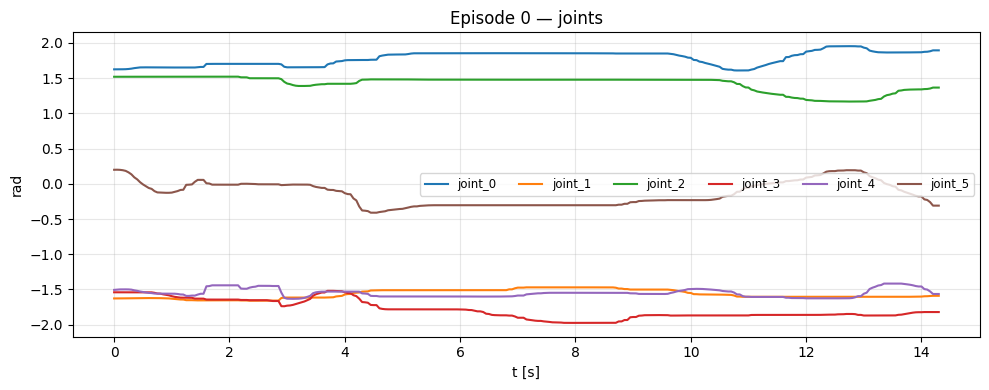

In [13]:
joints = stack("observation.state.joints")
if joints is not None:
    plt.figure(figsize=(10, 4))
    for i in range(joints.shape[1]):
        plt.plot(t, joints[:, i], label=f"joint_{i}")
    plt.xlabel("t [s]")
    plt.ylabel("rad")
    plt.title(f"Episode {EPISODE_INDEX} \u2014 joints")
    plt.legend(ncol=6, fontsize="small")
    plt.grid(alpha=0.3)
    plt.tight_layout()
else:
    print("No observation.state.joints column.")

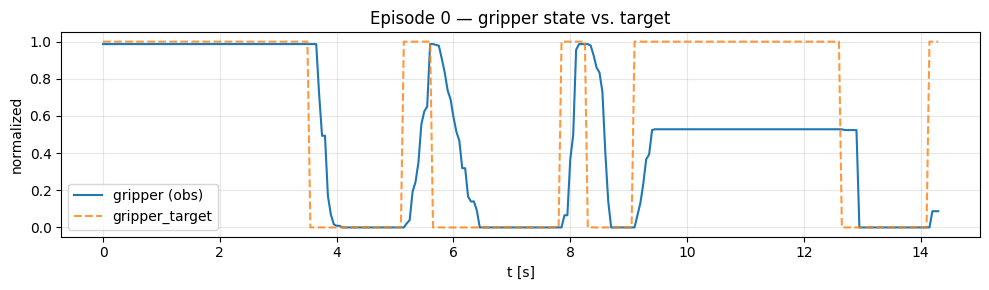

In [14]:
grip = stack("observation.state.gripper")
grip_target = stack("observation.state.gripper_target")

if grip is not None:
    plt.figure(figsize=(10, 3))
    plt.plot(t, grip[:, 0], label="gripper (obs)")
    if grip_target is not None:
        plt.plot(t, grip_target[:, 0], linestyle="--", alpha=0.8, label="gripper_target")
    plt.xlabel("t [s]")
    plt.ylabel("normalized")
    plt.title(f"Episode {EPISODE_INDEX} \u2014 gripper state vs. target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
else:
    print("No observation.state.gripper column.")

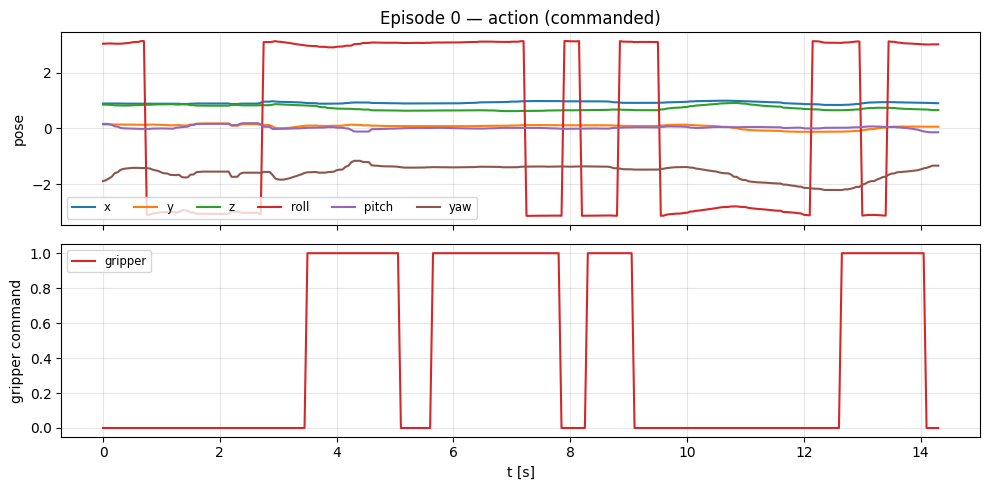

In [15]:
action = stack("action")
if action is not None:
    action_names = (
        info.get("features", {}).get("action", {}).get("names")
        or [f"a_{i}" for i in range(action.shape[1])]
    )
    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axes[0].set_title(f"Episode {EPISODE_INDEX} \u2014 action (commanded)")
    for i in range(min(6, action.shape[1])):
        axes[0].plot(t, action[:, i], label=action_names[i])
    axes[0].set_ylabel("pose")
    axes[0].legend(ncol=6, fontsize="small")
    axes[0].grid(alpha=0.3)
    axes[1].plot(t, action[:, -1], color="C3", label=action_names[-1])
    axes[1].set_ylabel("gripper command")
    axes[1].set_xlabel("t [s]")
    axes[1].legend(fontsize="small")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
else:
    print("No action column.")

## 6b. Sanity check: action should lead or equal observation

After the recording fix, the gripper component of `action` is the **commanded** target
(`env.gripper.target`), not the current reading. If they're identical everywhere either the
operator never touched the gripper or `/target_gripper_state` was never published. If action
leads observation, the recording is healthy.


In [16]:
if grip is not None and action is not None:
    grip_action_col = action[:, -1]
    diff = grip_action_col - grip[:, 0]
    print(f"gripper action range: [{grip_action_col.min():.3f}, {grip_action_col.max():.3f}]")
    print(f"gripper obs range:    [{grip[:, 0].min():.3f}, {grip[:, 0].max():.3f}]")
    print(f"max(action - obs):    {np.max(np.abs(diff)):.4f}")
    if np.allclose(grip_action_col, grip[:, 0], atol=1e-3):
        print("\u26a0  action == observation for the whole episode \u2014 tracker probably off.")
    else:
        print("\u2713 action differs from observation \u2014 looks like a real demonstration.")

gripper action range: [0.000, 1.000]
gripper obs range:    [0.000, 0.987]
max(action - obs):    1.0000
✓ action differs from observation — looks like a real demonstration.


## 7. Peek at a few video frames

For v3 the bundled mp4 holds many episodes; we slice by `from_timestamp`/`to_timestamp` from
the episodes parquet. For v2 the file *is* the episode.


In [17]:
video_specs = reader.episode_video_specs(EPISODE_INDEX)
for key, (mp4, ft, tt) in video_specs.items():
    rel = mp4.relative_to(DATASET_DIR)
    print(f"  {key}: {rel}   t=[{ft:.3f}, {tt:.3f}]   dur={tt-ft:.3f}s")
if not video_specs:
    print("(no videos for this episode)")

  observation.images.camera: videos/observation.images.camera/chunk-000/file-000.mp4   t=[0.000, 14.350]   dur=14.350s


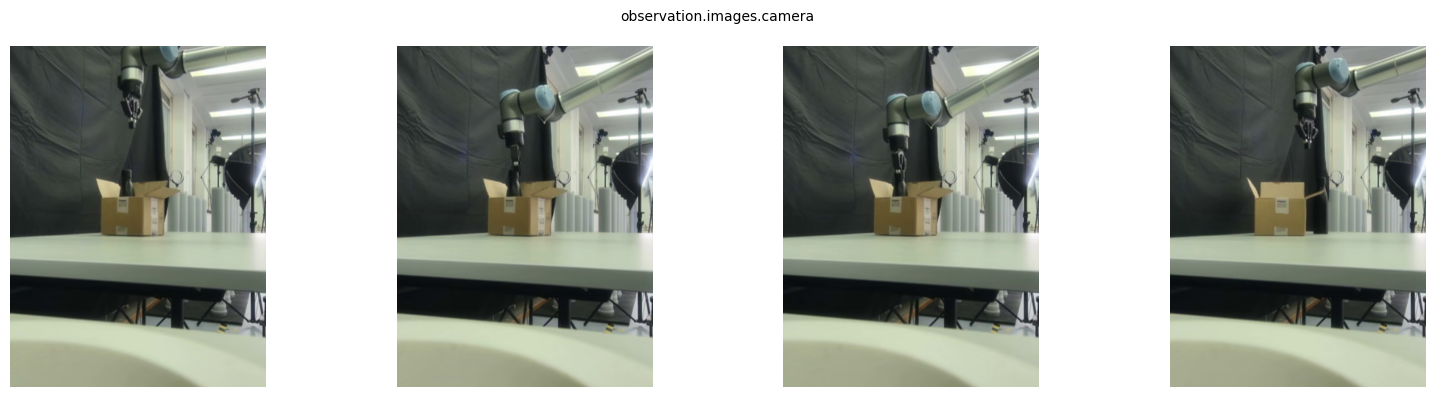

In [18]:
def read_frames(mp4_path: Path, from_ts: float, to_ts: float, n: int = 4) -> list[np.ndarray]:
    """Return n evenly-spaced frames from the [from_ts, to_ts] slice of an mp4."""
    try:
        import av
    except ImportError:
        import imageio.v3 as iio
        all_frames = list(iio.imiter(str(mp4_path)))
        if not all_frames:
            return []
        idxs = np.linspace(0, len(all_frames) - 1, min(n, len(all_frames))).astype(int)
        return [all_frames[i] for i in idxs]

    container = av.open(str(mp4_path))
    stream = container.streams.video[0]
    seek_ts = int(max(from_ts - 0.1, 0.0) * av.time_base)
    container.seek(seek_ts, any_frame=False, backward=True)
    frames: list[tuple[float, np.ndarray]] = []
    for frame in container.decode(video=0):
        ts = float(frame.pts * stream.time_base) if frame.pts is not None else 0.0
        if ts < from_ts:
            continue
        if ts > to_ts:
            break
        frames.append((ts, frame.to_ndarray(format="rgb24")))
    container.close()
    if not frames:
        return []
    targets = np.linspace(from_ts, to_ts, n)
    picked = []
    for tgt_ts in targets:
        i = int(np.argmin([abs(ts - tgt_ts) for ts, _ in frames]))
        picked.append(frames[i][1])
    return picked


for key, (mp4, ft, tt) in video_specs.items():
    frames = read_frames(mp4, ft, tt, n=4)
    if not frames:
        print(f"no frames decoded from {mp4.name}")
        continue
    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 4))
    if len(frames) == 1:
        axes = [axes]
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.set_axis_off()
    fig.suptitle(f"{key}", fontsize=10)
    plt.tight_layout()

## 8. Multi-episode summary

One row per episode with length, duration, and a few action-magnitude stats. Useful for
spotting the episode where you forgot to actually move the robot.


In [19]:
rows = []
for _, ep in reader.episodes_df.iterrows():
    idx = int(ep["episode_index"])
    d = reader.load_episode(idx)
    row = {"episode": idx, "n_frames": len(d)}
    if "action" in d.columns:
        a = np.stack([np.asarray(v, dtype=np.float32) for v in d["action"].values])
        row["action_pose_std"] = float(np.std(a[:, :6]))
        row["action_gripper_range"] = float(a[:, -1].max() - a[:, -1].min())
    if "timestamp" in d.columns:
        ts = d["timestamp"].to_numpy()
        row["duration_s"] = float(ts[-1] - ts[0]) if len(ts) > 1 else 0.0
    rows.append(row)
if rows:
    display(pd.DataFrame(rows))
else:
    print("no episodes")

,episode,n_frames,action_pose_std,action_gripper_range,duration_s
0,0,287,1.486840,1.0,14.300000
1,1,1700,1.494057,1.0,84.949997
